## **Bayesian Logistic Regression for Titanic Survival Prediction**

This notebook details the end-to-end process of building, training, and evaluating a Bayesian Logistic Regression model using PyMC for predicting Titanic survival. It also emphasizes the importance of uncertainty quantification inherent in Bayesian methods.

1.  **Data Preparation:**
    *   The `titanic` dataset was loaded using `seaborn`.
    *   Rows with missing 'age' values were dropped to simplify the model.
    *   Relevant features (`pclass`, `age`, `gender`) and the target (`survived`) were selected.
    *   The data was split into training and testing sets (80% training, 20% testing) using `sklearn.model_selection.train_test_split`.

2.  **Bayesian Model Definition (PyMC):**
    *   A PyMC model was defined using `pm.Model()`.
    *   `Normal` priors were set for the `intercept` and the `beta` coefficients corresponding to `pclass`, `age`, and `gender`.
    *   Logits (linear model output) were calculated as the sum of the intercept and feature coefficients multiplied by their respective training data values.
    *   Probabilities were derived from the logits using `pm.math.sigmoid`.
    *   The `survived` outcome was modeled as a `pm.Bernoulli` distribution, observed with the training labels `y_train`.

3.  **MCMC Sampling (Model Training):**
    *   The model was trained using `pm.sample` to draw 2000 posterior samples, preceded by 1000 tuning steps.
    *   A `target_accept` of 0.95 was specified to ensure robust sampling.

4.  **Prediction and Uncertainty Calculation:**
    *   Posterior samples for the `intercept` and `beta` coefficients were extracted from the `trace.posterior` object after stacking the 'chain' and 'draw' dimensions (`combined_posterior = trace.posterior.stack(sample=("chain", "draw"))`). This ensured correct iteration over scalar samples.
    *   For each posterior sample, logits were calculated for the `X_test` data.
    *   These logits were then converted to probabilities for each test sample across all posterior samples, resulting in `probabilities_samples`.
    *   The mean predicted probability (`probabilities`) and the uncertainty (standard deviation of `probabilities_samples` across the posterior dimension, named `uncertainty`) were calculated for each test sample.

5.  **Model Evaluation:**
    *   Binary predictions (`y_pred`) were obtained by thresholding the mean predicted probabilities at 0.5.
    *   Standard classification metrics (Accuracy, Precision, Recall, and AUC) were calculated, showing the model's performance on the test set.

6.  **Uncertainty Visualization:**
    *   A `prediction_df` DataFrame was created to display actual values, binary predictions, mean predicted probabilities, and their associated uncertainty (standard deviation) for each test sample.
    *   An error bar plot was generated to visually represent the mean predicted probabilities and their uncertainty for each test sample.


In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import seaborn as sns

In [2]:
titanic = sns.load_dataset('titanic')

# Drop rows with missing age
titanic = titanic.dropna(subset=['age'])

# Encode gender: male=0, female=1
titanic['gender'] = titanic['sex'].map({'male': 0, 'female': 1})

# Select features and target
features = ['pclass', 'age', 'gender']
X = titanic[features]
y = titanic['survived']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((571, 3), (571,), (143, 3), (143,))

In [5]:
with pm.Model() as model:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    beta_pclass = pm.Normal('beta_pclass', mu=0, sigma=10)
    beta_age = pm.Normal('beta_age', mu=0, sigma=10)
    beta_gender = pm.Normal('beta_gender', mu=0, sigma=10)

    # Linear model
    logits = (intercept +
              beta_pclass * X_train['pclass'] +
              beta_age * X_train['age'] +
              beta_gender * X_train['gender'])

    probability = pm.Deterministic('probability', pm.math.sigmoid(logits))
    observed = pm.Bernoulli('observed', p=probability, observed=y_train)

In [6]:
with model:
    trace = pm.sample(2000, tune=1000, target_accept=0.95, random_seed=42)

Output()

In [7]:
logits_samples = []

# Stack chain and draw dimensions to get a single 'sample' dimension
combined_posterior = trace.posterior.stack(sample=("chain", "draw"))

# Extract all samples for each parameter as 1D numpy arrays
intercept_all_samples = combined_posterior['intercept'].values
beta_pclass_all_samples = combined_posterior['beta_pclass'].values
beta_age_all_samples = combined_posterior['beta_age'].values
beta_gender_all_samples = combined_posterior['beta_gender'].values

num_total_samples = len(intercept_all_samples) # This will be num_chains * num_draws_per_chain

for i in range(num_total_samples):
    intercept_sample = intercept_all_samples[i]
    beta_pclass_sample = beta_pclass_all_samples[i]
    beta_age_sample = beta_age_all_samples[i]
    beta_gender_sample = beta_gender_all_samples[i]

    # X_test columns are pandas Series, which interact correctly with scalar numpy floats
    logits = (intercept_sample +
              beta_pclass_sample * X_test['pclass'] +
              beta_age_sample * X_test['age'] +
              beta_gender_sample * X_test['gender'])
    logits_samples.append(logits)

# Convert list of Series/arrays to a 2D numpy array for easier calculation
# Each element in logits_samples is a Series of length len(X_test).
# So logits_samples_array will be (num_total_samples, len(X_test))
logits_samples_array = np.array(logits_samples)

# Average logits across samples (axis=0)
logits_mean = np.mean(logits_samples_array, axis=0)

# Convert mean logits to probabilities
probabilities = 1 / (1 + np.exp(-logits_mean))

# Compute uncertainty as standard deviation of probabilities across samples
probabilities_samples = 1 / (1 + np.exp(-logits_samples_array))
uncertainty = np.std(probabilities_samples, axis=0)

In [8]:
# Threshold to make binary predictions
y_pred = (probabilities > 0.5).astype(int)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, probabilities)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'AUC: {auc:.2f}')

Accuracy: 0.74
Precision: 0.67
Recall: 0.68
AUC: 0.81


In [9]:
prediction_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Binary': y_pred,
    'Predicted_Probability': probabilities,
    'Uncertainty_StdDev': uncertainty
}, index=X_test.index)

display(prediction_df.head())

,Actual,Predicted_Binary,Predicted_Probability,Uncertainty_StdDev
149,0,0,0.150685,0.022831
407,1,0,0.499646,0.068398
53,1,1,0.826120,0.027827
369,1,1,0.956841,0.013104
818,0,0,0.043422,0.011927


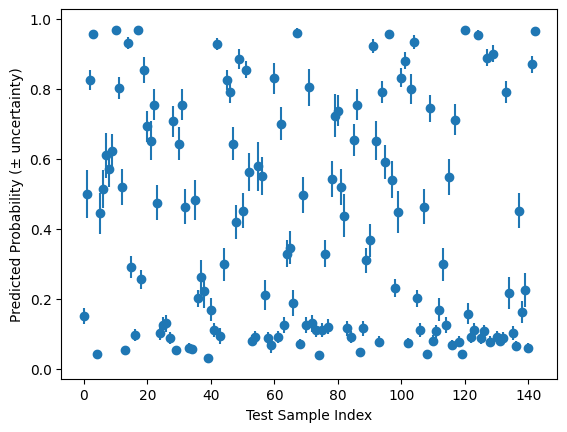

In [10]:
# Plot uncertainty vs probability
plt.errorbar(range(len(y_test)), probabilities, uncertainty, fmt='o')
plt.xlabel('Test Sample Index')
plt.ylabel('Predicted Probability (± uncertainty)')
plt.show()

**Plot Interpretation:** This error bar plot visualizes the predicted survival probability for each test passenger. The central dot represents the mean predicted probability, and the vertical error bars indicate the model's uncertainty (±1 standard deviation of posterior probabilities). Notice that the model exhibits lower uncertainty for predictions close to 0 (unlikely to survive) or 1 (likely to survive). Conversely, uncertainty is highest for predictions in the intermediate range (0.4-0.6), signifying situations where the model is least confident due to ambiguous data. This capability to quantify predictive uncertainty is a core advantage of Bayesian modeling, providing a more comprehensive understanding of the model's 'belief' for each prediction.